## Yolo 26 Model! 
Followed the tutorial here!: https://blog.roboflow.com/how-to-train-yolo26-custom-data/ 

Below is the code I used to train the Yolo26 model with yolo26_training_images. I used Visual Studio Code with the Google Collab extension for GPU use. I tried my best to explain my steps below but if you have any questions please don't hesitate to reach out! 

It can be a little tricky when working with Collab in VSC because I needed to clone our repo from Github. I made note of this in the notebook below but make sure when running, you change the link to be your username. 

In [1]:
!pip install "ultralytics>=8.4.0" supervision

In [ ]:
# Change this guy to your username! 
# EX: https://github.com/USERNAME/FIRST-Robotics-Competition-Data-Challenge.git 

!git clone https://github.com/KennedyWendl/FIRST-Robotics-Competition-Data-Challenge.git

# And then to the branch you are working on!
# For the code below I am working off of the yolo26 branch but if you are not make sure to cd into your branch then change below  
# EX: ... checkout "YOUR BRANCH" 

!git -C /content/FIRST-Robotics-Competition-Data-Challenge checkout yolo26

fatal: destination path 'FIRST-Robotics-Competition-Data-Challenge' already exists and is not an empty directory.
Already on 'yolo26'
Your branch is up to date with 'origin/yolo26'.


In [ ]:
# Confirming I connected to our repo
import os

os.chdir('/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge')

print("Current directory:", os.getcwd())
print("Files:", os.listdir(os.getcwd()))

Current directory: /content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge
Files: ['yolo26_training_images', 'README.md', '.git', 'training', 'yolov8_training_images', 'data_source']


In [11]:
# Training the YOLOv8 model on training set from yolo26_training_images 
from ultralytics import YOLO

# PAth 
os.chdir('/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images')

yaml_path = os.path.join(os.getcwd(), 'data.yaml')
print(yaml_path)

model = YOLO('yolo26m.pt')

model.train(
    data= yaml_path,
    epochs=20,
    imgsz=640,
    plots=True
)

/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images/data.yaml
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b1dad91490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [14]:
# Prints saved path of model 
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            best = os.path.join(root, file)
            print(best)


/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images/runs/detect/train/weights/best.pt


Testing on: /content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images/valid/images/framequal56_0054_jpg.rf.128b86551e8df51a27a18fce3fe13d76.jpg


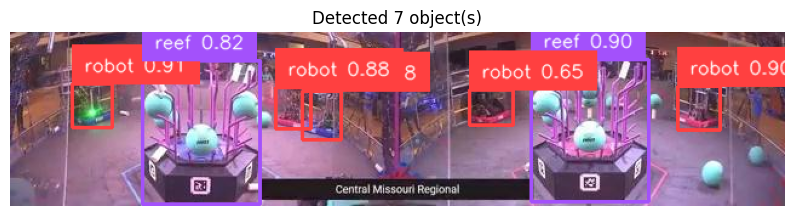

In [21]:
# Validation of model!
import random
import glob
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
from PIL import Image

# Loading trained model from path
model = YOLO(best)

# Randomly picking image to test on 

# Validation image path 
val_images = glob.glob('/content/FIRST-Robotics-Competition-Data-Challenge/FIRST-Robotics-Competition-Data-Challenge/yolo26_training_images/valid/images/*')

# Choosing a random image 
test_image_path = random.choice(val_images)
print("Testing on:", test_image_path)

# Running inference
image = Image.open(test_image_path)
result = model.predict(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

# Annotate the image with bounding boxes and labels
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

class_names = ['reef', 'robot']
labels = [f"{class_names[cls]} {conf:.2f}" for cls, conf in zip(detections.class_id, detections.confidence)]

annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Displaying result
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.axis("off")
plt.title(f"Detected {len(detections)} object(s)")
plt.show()